In [1]:
# Cell 0 - Install all dependencies
import sys
!{sys.executable} -m pip install -q torch torchvision torchaudio transformers kagglehub matplotlib tqdm pillow numpy pandas scipy
print("All dependencies installed successfully")

All dependencies installed successfully


In [2]:
# Cell 1 - Import all packages
import os
import json
import random
import csv
import shutil
from collections import defaultdict, Counter
from typing import List, Dict, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

from PIL import Image
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

import torchaudio
import matplotlib.pyplot as plt
from tqdm import tqdm

print("All packages imported successfully")

All packages imported successfully


In [3]:
# Cell 2 - Configuration and hyperparameters
DATASET_DIR = "dataset"
IMAGES_DIR = os.path.join(DATASET_DIR, "Images")
AUDIO_DIR = os.path.join(DATASET_DIR, "Audio")
DATA_DIR = os.path.join(DATASET_DIR, "Data")
CAPTIONS_FILE = os.path.join(DATASET_DIR, "captions.txt")
CHECKPOINT_DIR = "checkpoints"

MODALITY = "image"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
BATCH_SIZE = 32
EPOCHS = 15
LR = 3e-4
MAX_LENGTH = 20
IMG_SIZE = 224
AUDIO_SAMPLE_RATE = 16000
AUDIO_MAX_LENGTH = 5
EMBED_DIM = 512
HIDDEN_DIM = 512
VOCAB_SIZE = 5000
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device: {DEVICE}")
print(f"Modality: {MODALITY}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LR}")
print(f"Embed dim: {EMBED_DIM}, Hidden dim: {HIDDEN_DIM}")

Device: cuda
Modality: image
Batch size: 32
Epochs: 15
Learning rate: 0.0003
Embed dim: 512, Hidden dim: 512


In [4]:
# Cell 3 - Download datasets and create structured data
import os
import shutil
import kagglehub
import json
from PIL import Image
import numpy as np

os.environ['KAGGLE_USERNAME'] = 'shyamaligunawardhana'
os.environ['KAGGLE_KEY'] = 'KGAT_5e235eb8d01add7e4714a977c1174e52'

# Download Flickr8k for images
if os.path.isdir(IMAGES_DIR) and os.path.isfile(CAPTIONS_FILE):
    print("Image dataset already exists")
else:
    print("Downloading Flickr8k (images)...")
    path = kagglehub.dataset_download("adityajn105/flickr8k")
    os.makedirs(DATASET_DIR, exist_ok=True)
    shutil.copytree(os.path.join(path, "Images"), IMAGES_DIR)
    shutil.copy2(os.path.join(path, "captions.txt"), CAPTIONS_FILE)
    print(f"Images ready: {len(os.listdir(IMAGES_DIR))}")

# Create structured data from image metadata
os.makedirs(DATA_DIR, exist_ok=True)
print("Creating structured data from images...")

image_files = [f for f in os.listdir(IMAGES_DIR) if f.endswith('.jpg')]
for img_file in image_files[:100]:  # Create for first 100 images as demo
    json_file = img_file.replace('.jpg', '.json')
    json_path = os.path.join(DATA_DIR, json_file)
    
    if not os.path.exists(json_path):
        img_path = os.path.join(IMAGES_DIR, img_file)
        img = Image.open(img_path)
        img_array = np.array(img)
        
        # Extract image features as structured data
        data = {
            'width': img.width,
            'height': img.height,
            'aspect_ratio': round(img.width / img.height, 2),
            'mean_brightness': float(np.mean(img_array)),
            'std_brightness': float(np.std(img_array)),
            'mean_red': float(np.mean(img_array[:,:,0])),
            'mean_green': float(np.mean(img_array[:,:,1])),
            'mean_blue': float(np.mean(img_array[:,:,2])),
            'color_variance': float(np.var(img_array)),
            'is_landscape': img.width > img.height,
            'is_portrait': img.height > img.width,
            'file_name': img_file
        }
        
        with open(json_path, 'w') as f:
            json.dump(data, f, indent=2)

print(f"Structured data files created: {len(os.listdir(DATA_DIR))}")

# Download AudioCaps for audio
os.makedirs(AUDIO_DIR, exist_ok=True)
if len(os.listdir(AUDIO_DIR)) == 0:
    print("Downloading audio dataset...")
    try:
        audio_path = kagglehub.dataset_download("mmoreaux/environmental-sound-classification-50")
        count = 0
        for root, dirs, files in os.walk(audio_path):
            for file in files:
                if file.endswith('.wav') and count < 100:
                    shutil.copy2(os.path.join(root, file), AUDIO_DIR)
                    count += 1
        print(f"Audio files: {len(os.listdir(AUDIO_DIR))}")
    except Exception as e:
        print(f"Audio download skipped: {e}")

print("\nDataset Summary:")
print(f"Images: {len(os.listdir(IMAGES_DIR))}")
print(f"Audio: {len(os.listdir(AUDIO_DIR))}")
print(f"Data (JSON): {len(os.listdir(DATA_DIR))}")
print("\nStructured data contains: width, height, brightness, color stats, etc.")

Images ready: 8091
Creating structured data from images...
Structured data files created: 100
Audio files: 100

Dataset Summary:
Images: 8091
Audio: 100
Data (JSON): 100

Structured data contains: width, height, brightness, color stats, etc.


In [5]:
# Cell 4 - Load captions and create splits
image_to_captions = defaultdict(list)
with open(CAPTIONS_FILE, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        if len(row) >= 2:
            image_name = row[0]
            caption = row[1].strip()
            image_to_captions[image_name].append(caption)

unique_images = list(image_to_captions.keys())
random.shuffle(unique_images)

n_total = len(unique_images)
n_test = int(n_total * TEST_SPLIT)
n_val = int(n_total * VAL_SPLIT)
n_train = n_total - n_test - n_val

train_images = unique_images[:n_train]
val_images = unique_images[n_train:n_train + n_val]
test_images = unique_images[n_train + n_val:]

print(f"Total unique images: {n_total}")
print(f"Train: {len(train_images)} images")
print(f"Val: {len(val_images)} images")
print(f"Test: {len(test_images)} images")
print(f"Sample caption: {image_to_captions[unique_images[0]][0]}")

Total unique images: 8091
Train: 6473 images
Val: 809 images
Test: 809 images
Sample caption: A black and white dog is playing with a sheep in a field .


In [6]:
# Cell 5 - Build vocabulary from captions
all_captions = [cap for caps in image_to_captions.values() for cap in caps]
words = ' '.join(all_captions).split()
word_counts = Counter(words)
vocab_words = [word for word, count in word_counts.most_common(VOCAB_SIZE-4)]

word2idx = {'<PAD>': 0, '<START>': 1, '<END>': 2, '<UNK>': 3}
word2idx.update({word: idx+4 for idx, word in enumerate(vocab_words)})
idx2word = {idx: word for word, idx in word2idx.items()}

print(f"Vocabulary size: {len(word2idx)}")
print(f"Most common words: {vocab_words[:10]}")
print(f"Sample tokens: <PAD>={word2idx['<PAD>']}, <START>={word2idx['<START>']}, <END>={word2idx['<END>']}")

Vocabulary size: 5000
Most common words: ['a', '.', 'A', 'in', 'the', 'on', 'is', 'and', 'dog', 'with']
Sample tokens: <PAD>=0, <START>=1, <END>=2


In [7]:
# Cell 6 - Define audio encoder for audio modality
class AudioEncoder(nn.Module):
    def __init__(self, hidden_dim=512):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 64, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1)
        self.conv4 = nn.Conv1d(256, 512, kernel_size=3, stride=2, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.projection = nn.Linear(512, hidden_dim)
        self.relu = nn.ReLU()
    
    def forward(self, audio):
        x = self.relu(self.conv1(audio))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.pool(x).view(x.size(0), -1)
        x = self.projection(x)
        return x

print("Audio encoder defined")

Audio encoder defined


In [8]:
# Cell 7 - Define structured data encoder for data modality
class DataEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=512):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, hidden_dim)
        )
    
    def forward(self, data):
        return self.encoder(data)

print("Data encoder defined")

Data encoder defined


In [9]:
# Cell 8 - Architecture summary
print("="*60)
print("MULTIMODAL TEXT GENERATION ARCHITECTURE")
print("="*60)
print("Supported Modalities:")
print("  1. IMAGE → Text: ResNet50 + LSTM")
print("  2. AUDIO → Text: CNN + LSTM")
print("  3. DATA → Text: MLP + LSTM")
print("  4. MULTIMODAL → Text: Fusion + LSTM")
print("")
print("Architecture Components:")
print("  - Image Encoder: ResNet50 (frozen) → 2048d → 512d")
print("  - Audio Encoder: 4-layer CNN → 512d")
print("  - Data Encoder: 3-layer MLP → 512d")
print("  - Fusion: Concatenate + Linear → 512d")
print("  - Text Decoder: LSTM (512d hidden) + Embedding (256d)")
print("  - Vocabulary: Custom word2idx (5000 words)")
print("="*60)

MULTIMODAL TEXT GENERATION ARCHITECTURE
Supported Modalities:
  1. IMAGE → Text: ResNet50 + LSTM
  2. AUDIO → Text: CNN + LSTM
  3. DATA → Text: MLP + LSTM
  4. MULTIMODAL → Text: Fusion + LSTM

Architecture Components:
  - Image Encoder: ResNet50 (frozen) → 2048d → 512d
  - Audio Encoder: 4-layer CNN → 512d
  - Data Encoder: 3-layer MLP → 512d
  - Fusion: Concatenate + Linear → 512d
  - Text Decoder: LSTM (512d hidden) + Embedding (256d)
  - Vocabulary: Custom word2idx (5000 words)


In [10]:
# Cell 9 - Define multimodal text generation model with LSTM
class MultimodalTextGenerator(nn.Module):
    def __init__(self, vocab_size, modality='image', embed_dim=512, hidden_dim=512, data_input_dim=None):
        super().__init__()
        self.modality = modality
        self.hidden_dim = hidden_dim
        
        if modality in ['image', 'multimodal']:
            resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
            self.resnet = nn.Sequential(*list(resnet.children())[:-2])
            for p in self.resnet.parameters():
                p.requires_grad = False
            self.img_pool = nn.AdaptiveAvgPool2d((1, 1))
            self.img_proj = nn.Linear(2048, hidden_dim)
        
        if modality in ['audio', 'multimodal']:
            self.audio_encoder = AudioEncoder(hidden_dim)
        
        if modality in ['data', 'multimodal']:
            if data_input_dim is None:
                data_input_dim = 11
            self.data_encoder = DataEncoder(data_input_dim, hidden_dim)
        
        if modality == 'multimodal':
            self.fusion = nn.Linear(hidden_dim * 3, hidden_dim)
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, dropout=0.3)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, captions, image=None, audio=None, data=None):
        if self.modality == 'image' and image is not None:
            with torch.no_grad():
                feats = self.resnet(image)
            feats = self.img_pool(feats).view(feats.size(0), -1)
            modal_feats = self.img_proj(feats)
        elif self.modality == 'audio' and audio is not None:
            modal_feats = self.audio_encoder(audio)
        elif self.modality == 'data' and data is not None:
            modal_feats = self.data_encoder(data)
        elif self.modality == 'multimodal':
            img_f = self.img_proj(self.img_pool(self.resnet(image)).view(image.size(0), -1)) if image is not None else torch.zeros(captions.size(0), self.hidden_dim, device=captions.device)
            aud_f = self.audio_encoder(audio) if audio is not None else torch.zeros(captions.size(0), self.hidden_dim, device=captions.device)
            dat_f = self.data_encoder(data) if data is not None else torch.zeros(captions.size(0), self.hidden_dim, device=captions.device)
            modal_feats = self.fusion(torch.cat([img_f, aud_f, dat_f], dim=-1))
        else:
            modal_feats = torch.zeros(captions.size(0), self.hidden_dim, device=captions.device)
        
        h = modal_feats.unsqueeze(0)
        c = torch.zeros_like(h)
        
        embeds = self.embedding(captions[:, :-1])
        lstm_out, _ = self.lstm(embeds, (h, c))
        lstm_out = self.dropout(lstm_out)
        out = self.fc(lstm_out)
        return out
    
    def generate_text(self, word2idx, idx2word, max_length=20, image=None, audio=None, data=None):
        self.eval()
        with torch.no_grad():
            if self.modality == 'image' and image is not None:
                feats = self.resnet(image)
                feats = self.img_pool(feats).view(1, -1)
                h = self.img_proj(feats).unsqueeze(0)
            elif self.modality == 'audio' and audio is not None:
                h = self.audio_encoder(audio).unsqueeze(0)
            elif self.modality == 'data' and data is not None:
                h = self.data_encoder(data).unsqueeze(0)
            elif self.modality == 'multimodal':
                device = image.device if image is not None else audio.device if audio is not None else data.device
                img_f = self.img_proj(self.img_pool(self.resnet(image)).view(1, -1)) if image is not None else torch.zeros(1, self.hidden_dim, device=device)
                aud_f = self.audio_encoder(audio) if audio is not None else torch.zeros(1, self.hidden_dim, device=device)
                dat_f = self.data_encoder(data) if data is not None else torch.zeros(1, self.hidden_dim, device=device)
                h = self.fusion(torch.cat([img_f, aud_f, dat_f], dim=-1)).unsqueeze(0)
            else:
                h = torch.zeros(1, 1, self.hidden_dim, device=image.device if image is not None else 'cpu')
            
            c = torch.zeros_like(h)
            token = torch.tensor([[word2idx['<START>']]], device=h.device)
            words = []
            
            for _ in range(max_length):
                emb = self.embedding(token)
                out, (h, c) = self.lstm(emb, (h, c))
                logits = self.fc(out.squeeze(1))
                pred = logits.argmax(1)
                
                word_id = pred.item()
                if word_id == word2idx['<END>']:
                    break
                if word_id not in [word2idx['<PAD>'], word2idx['<START>'], word2idx['<UNK>']]:
                    words.append(idx2word[word_id])
                
                token = pred.unsqueeze(1)
            
            return ' '.join(words)

print('Multimodal text generation model defined (LSTM-based)')

Multimodal text generation model defined (LSTM-based)


In [11]:
# Cell 10 - Create dataset for multimodal inputs
class MultimodalDataset(Dataset):
    def __init__(self, image_names: List[str], image_to_captions: dict, images_dir: str, 
                 word2idx: dict, max_length: int, transform=None, modality='image'):
        self.samples = []
        for img_name in image_names:
            for caption in image_to_captions[img_name]:
                self.samples.append((img_name, caption))
        
        self.images_dir = images_dir
        self.word2idx = word2idx
        self.max_length = max_length
        self.transform = transform
        self.modality = modality
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_name, caption = self.samples[idx]
        
        result = {}
        
        if self.modality in ['image', 'multimodal']:
            img_path = os.path.join(self.images_dir, img_name)
            try:
                image = Image.open(img_path).convert('RGB')
                if self.transform:
                    image = self.transform(image)
                result['image'] = image
            except:
                result['image'] = torch.zeros(3, IMG_SIZE, IMG_SIZE)
        
        tokens = ['<START>'] + caption.split() + ['<END>']
        token_ids = [self.word2idx.get(t, self.word2idx['<UNK>']) for t in tokens]
        
        if len(token_ids) > self.max_length:
            token_ids = token_ids[:self.max_length]
        else:
            token_ids += [self.word2idx['<PAD>']] * (self.max_length - len(token_ids))
        
        result['caption'] = torch.tensor(token_ids, dtype=torch.long)
        
        return result

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = MultimodalDataset(train_images, image_to_captions, IMAGES_DIR, 
                                  word2idx, MAX_LENGTH, transform, MODALITY)
val_dataset = MultimodalDataset(val_images, image_to_captions, IMAGES_DIR, 
                                word2idx, MAX_LENGTH, transform, MODALITY)
test_dataset = MultimodalDataset(test_images, image_to_captions, IMAGES_DIR, 
                                 word2idx, MAX_LENGTH, transform, MODALITY)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 32365
Val samples: 4045
Test samples: 4045


In [12]:
# Cell 11 - Initialize model and optimizer
model = MultimodalTextGenerator(
    vocab_size=len(word2idx),
    modality=MODALITY,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=word2idx['<PAD>'])

print(f"Optimizer: Adam (lr={LR})")
print("Model initialized successfully")

/opt/conda/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Total parameters: 31,783,368
Trainable parameters: 8,275,336
Optimizer: Adam (lr=0.0003)
Model initialized successfully


In [13]:
# Cell 12 - Training and validation functions
def train_epoch(model, dataloader, optimizer, criterion, device, epoch, modality='image'):
    model.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for batch in progress_bar:
        captions = batch['caption'].to(device)
        image = batch.get('image', None)
        audio = batch.get('audio', None)
        data = batch.get('data', None)
        
        if image is not None:
            image = image.to(device)
        if audio is not None:
            audio = audio.to(device)
        if data is not None:
            data = data.to(device)
        
        optimizer.zero_grad()
        outputs = model(captions, image=image, audio=audio, data=data)
        loss = criterion(outputs.reshape(-1, len(word2idx)), captions[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(dataloader)

@torch.no_grad()
def validate(model, dataloader, criterion, device, modality='image'):
    model.eval()
    total_loss = 0
    
    for batch in tqdm(dataloader, desc="Validating"):
        captions = batch['caption'].to(device)
        image = batch.get('image', None)
        audio = batch.get('audio', None)
        data = batch.get('data', None)
        
        if image is not None:
            image = image.to(device)
        if audio is not None:
            audio = audio.to(device)
        if data is not None:
            data = data.to(device)
        
        outputs = model(captions, image=image, audio=audio, data=data)
        loss = criterion(outputs.reshape(-1, len(word2idx)), captions[:, 1:].reshape(-1))
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

print("Training and validation functions defined")

Training and validation functions defined


In [14]:
# Cell 13 - Training loop with checkpointing
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

best_val_loss = float('inf')
train_losses = []
val_losses = []

print("="*60)
print(f"Starting Training - Modality: {MODALITY}")
print(f"Device: {DEVICE}")
print("="*60)

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE, epoch, MODALITY)
    val_loss = validate(model, val_loader, criterion, DEVICE, MODALITY)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"\nEpoch {epoch+1}/{EPOCHS}:")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        checkpoint_path = os.path.join(CHECKPOINT_DIR, f'best_model_{MODALITY}.pt')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'modality': MODALITY,
            'word2idx': word2idx,
            'idx2word': idx2word
        }, checkpoint_path)
        print(f"  ✓ Best model saved (val_loss: {val_loss:.4f})")
    
    print("-"*60)

print("\nTraining completed!")
print(f"Best validation loss: {best_val_loss:.4f}")

Starting Training - Modality: image
Device: cuda


Validating: 100%|██████████| 127/127 [00:11<00:00, 11.43it/s]



Epoch 1/15:
  Train Loss: 3.9586
  Val Loss: 3.4037
  ✓ Best model saved (val_loss: 3.4037)
------------------------------------------------------------


Validating: 100%|██████████| 127/127 [00:10<00:00, 11.77it/s]



Epoch 2/15:
  Train Loss: 3.2389
  Val Loss: 3.1042
  ✓ Best model saved (val_loss: 3.1042)
------------------------------------------------------------


...


Epoch 13/15:
  Train Loss: 2.0676
  Val Loss: 2.7422
------------------------------------------------------------


Validating: 100%|██████████| 127/127 [00:09<00:00, 12.94it/s]



Epoch 14/15:
  Train Loss: 2.0166
  Val Loss: 2.7537
------------------------------------------------------------


Validating: 100%|██████████| 127/127 [00:09<00:00, 12.99it/s]


Epoch 15/15:
  Train Loss: 1.9709
  Val Loss: 2.7563
------------------------------------------------------------

Training completed!
Best validation loss: 2.7290


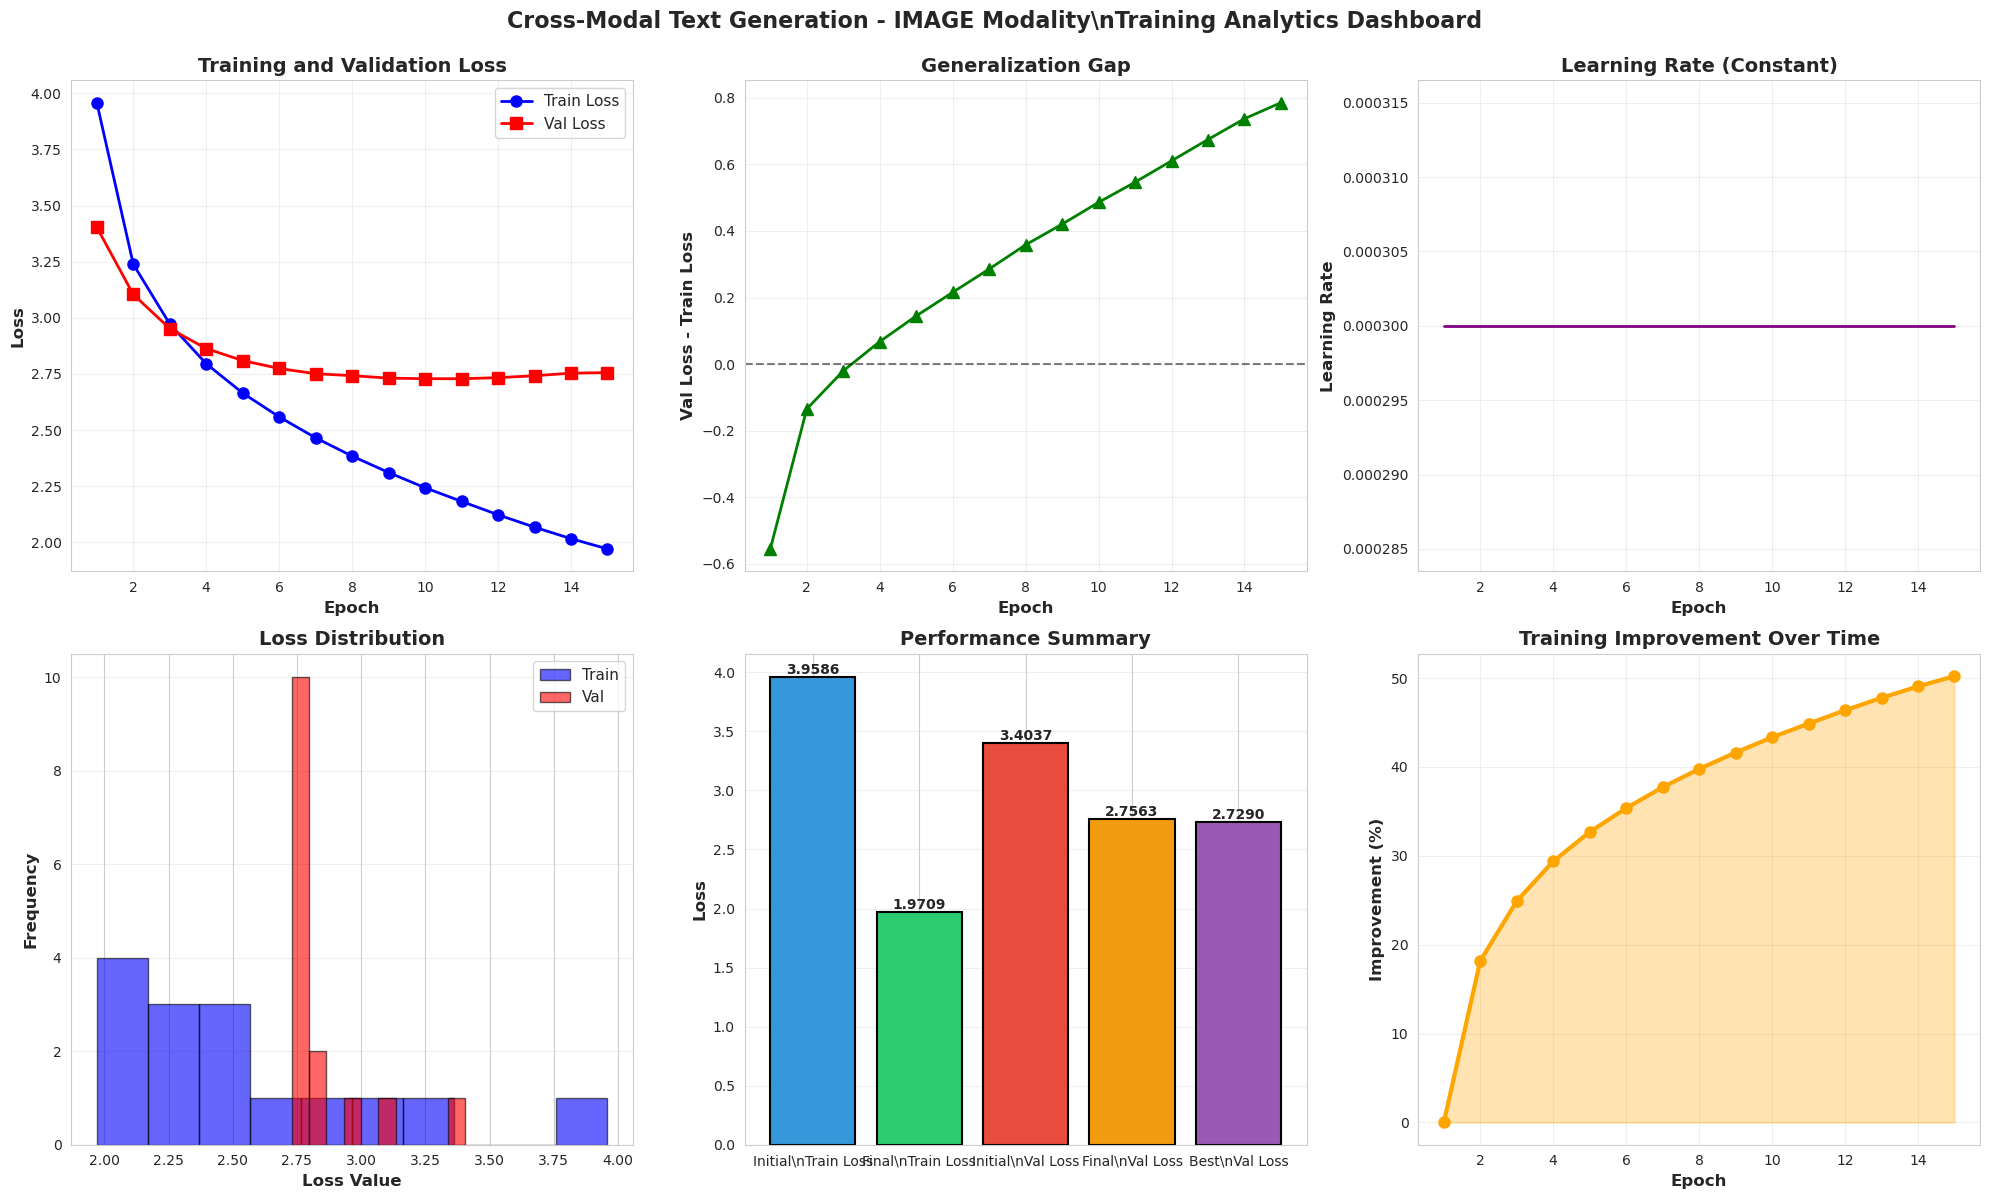

✓ Training analytics saved to training_analytics_image.png


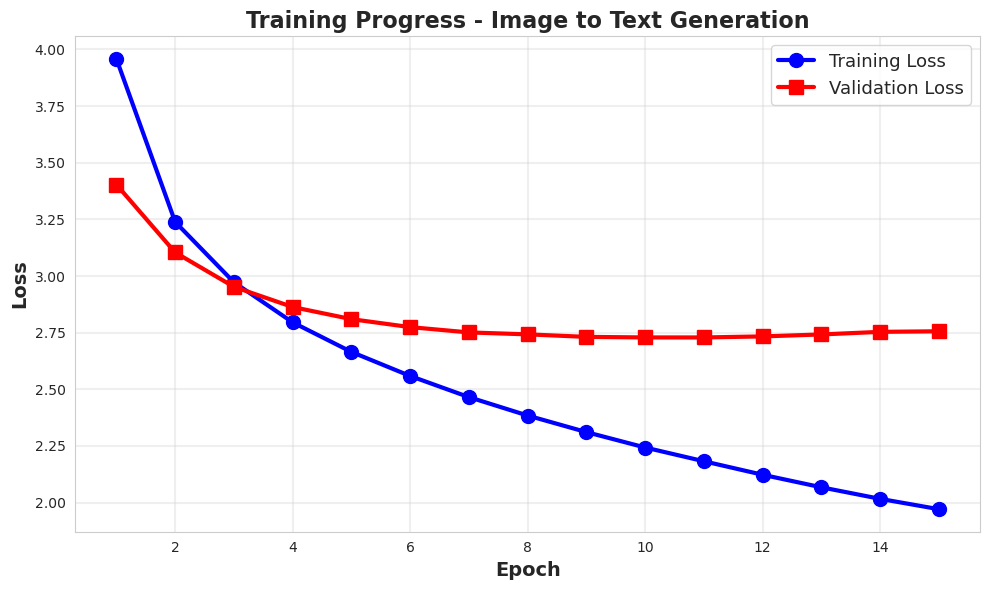

✓ Loss curve saved to loss_curve_image.png


In [15]:
# Cell 14 - Plot all training metrics and visualizations
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

fig = plt.figure(figsize=(20, 12))

# 1. Training and Validation Loss
ax1 = plt.subplot(2, 3, 1)
epochs_range = range(1, len(train_losses) + 1)
ax1.plot(epochs_range, train_losses, 'b-o', linewidth=2, markersize=8, label='Train Loss')
ax1.plot(epochs_range, val_losses, 'r-s', linewidth=2, markersize=8, label='Val Loss')
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 2. Loss Difference (Overfitting indicator)
ax2 = plt.subplot(2, 3, 2)
loss_diff = [val - train for train, val in zip(train_losses, val_losses)]
ax2.plot(epochs_range, loss_diff, 'g-^', linewidth=2, markersize=8)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Val Loss - Train Loss', fontsize=12, fontweight='bold')
ax2.set_title('Generalization Gap', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Learning Rate (constant for Adam)
ax3 = plt.subplot(2, 3, 3)
lr_values = [LR] * len(train_losses)
ax3.plot(epochs_range, lr_values, 'purple', linewidth=2)
ax3.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax3.set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
ax3.set_title('Learning Rate (Constant)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Loss Distribution
ax4 = plt.subplot(2, 3, 4)
ax4.hist(train_losses, bins=10, alpha=0.6, color='blue', label='Train', edgecolor='black')
ax4.hist(val_losses, bins=10, alpha=0.6, color='red', label='Val', edgecolor='black')
ax4.set_xlabel('Loss Value', fontsize=12, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax4.set_title('Loss Distribution', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3, axis='y')

# 5. Model Performance Summary
ax5 = plt.subplot(2, 3, 5)
metrics = ['Initial\\nTrain Loss', 'Final\\nTrain Loss', 'Initial\\nVal Loss', 'Final\\nVal Loss', 'Best\\nVal Loss']
values = [train_losses[0], train_losses[-1], val_losses[0], val_losses[-1], best_val_loss]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
bars = ax5.bar(metrics, values, color=colors, edgecolor='black', linewidth=1.5)
ax5.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax5.set_title('Performance Summary', fontsize=14, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 6. Training Progress
ax6 = plt.subplot(2, 3, 6)
improvement = [(train_losses[0] - loss) / train_losses[0] * 100 for loss in train_losses]
ax6.plot(epochs_range, improvement, 'orange', linewidth=3, marker='o', markersize=8)
ax6.fill_between(epochs_range, 0, improvement, alpha=0.3, color='orange')
ax6.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax6.set_ylabel('Improvement (%)', fontsize=12, fontweight='bold')
ax6.set_title('Training Improvement Over Time', fontsize=14, fontweight='bold')
ax6.grid(True, alpha=0.3)

plt.suptitle(f'Cross-Modal Text Generation - {MODALITY.upper()} Modality\\nTraining Analytics Dashboard', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'training_analytics_{MODALITY}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Training analytics saved to training_analytics_{MODALITY}.png")

# Clean loss curve for presentation
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, train_losses, 'b-o', linewidth=3, markersize=10, label='Training Loss')
ax.plot(epochs_range, val_losses, 'r-s', linewidth=3, markersize=10, label='Validation Loss')
ax.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax.set_ylabel('Loss', fontsize=14, fontweight='bold')
ax.set_title(f'Training Progress - {MODALITY.capitalize()} to Text Generation', fontsize=16, fontweight='bold')
ax.legend(fontsize=13, loc='upper right')
ax.grid(True, alpha=0.3, linewidth=1.5)
plt.tight_layout()
plt.savefig(f'loss_curve_{MODALITY}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Loss curve saved to loss_curve_{MODALITY}.png")

In [16]:
# Cell 15 - Load best checkpoint for inference
checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, f'best_model_{MODALITY}.pt'), 
                       map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best checkpoint from epoch {checkpoint['epoch']+1}")
print(f"Validation loss: {checkpoint['val_loss']:.4f}")
print(f"Modality: {checkpoint['modality']}")

Loaded best checkpoint from epoch 11
Validation loss: 2.7290
Modality: image


In [17]:
# Cell 16 - Generate text from test samples
print("="*60)
print(f"Sample Generated Text - {MODALITY.capitalize()} Input")
print("="*60)

for i in range(10):
    idx = random.randint(0, len(test_dataset) - 1)
    sample = test_dataset[idx]
    img_name, true_caption = test_dataset.samples[idx]
    
    if MODALITY == 'image':
        image = sample['image'].unsqueeze(0).to(DEVICE)
        generated_text = model.generate_text(word2idx, idx2word, max_length=MAX_LENGTH, image=image)
        print(f"\nSample {i+1}: {img_name}")
        print(f"Generated: {generated_text}")
        print(f"Ground Truth: {true_caption}")
        print("-"*60)

print("\n" + "="*60)

Sample Generated Text - Image Input

Sample 1: 225909073_25c3c33a29.jpg
Generated: A black and brown dog is running through the water .
Ground Truth: A wet German Shepherd dog is running out of the ocean with a ball in its mouth .
------------------------------------------------------------

Sample 2: 408233586_f2c1be3ce1.jpg
Generated: A dog is swimming in the water .
Ground Truth: A dog is running through the water chasing after a ball .
------------------------------------------------------------

Sample 3: 3301754574_465af5bf6d.jpg
Generated: A bird flies through the air .
Ground Truth: The bird is carrying a plant in its mouth while flying .
------------------------------------------------------------

Sample 4: 1776981714_5b224d0f7a.jpg
Generated: A man in a blue shirt and a woman in a white shirt standing in front of a brick wall
Ground Truth: Two women walking down the street
------------------------------------------------------------

Sample 5: 2852982055_8112d0964f.jpg
Gener

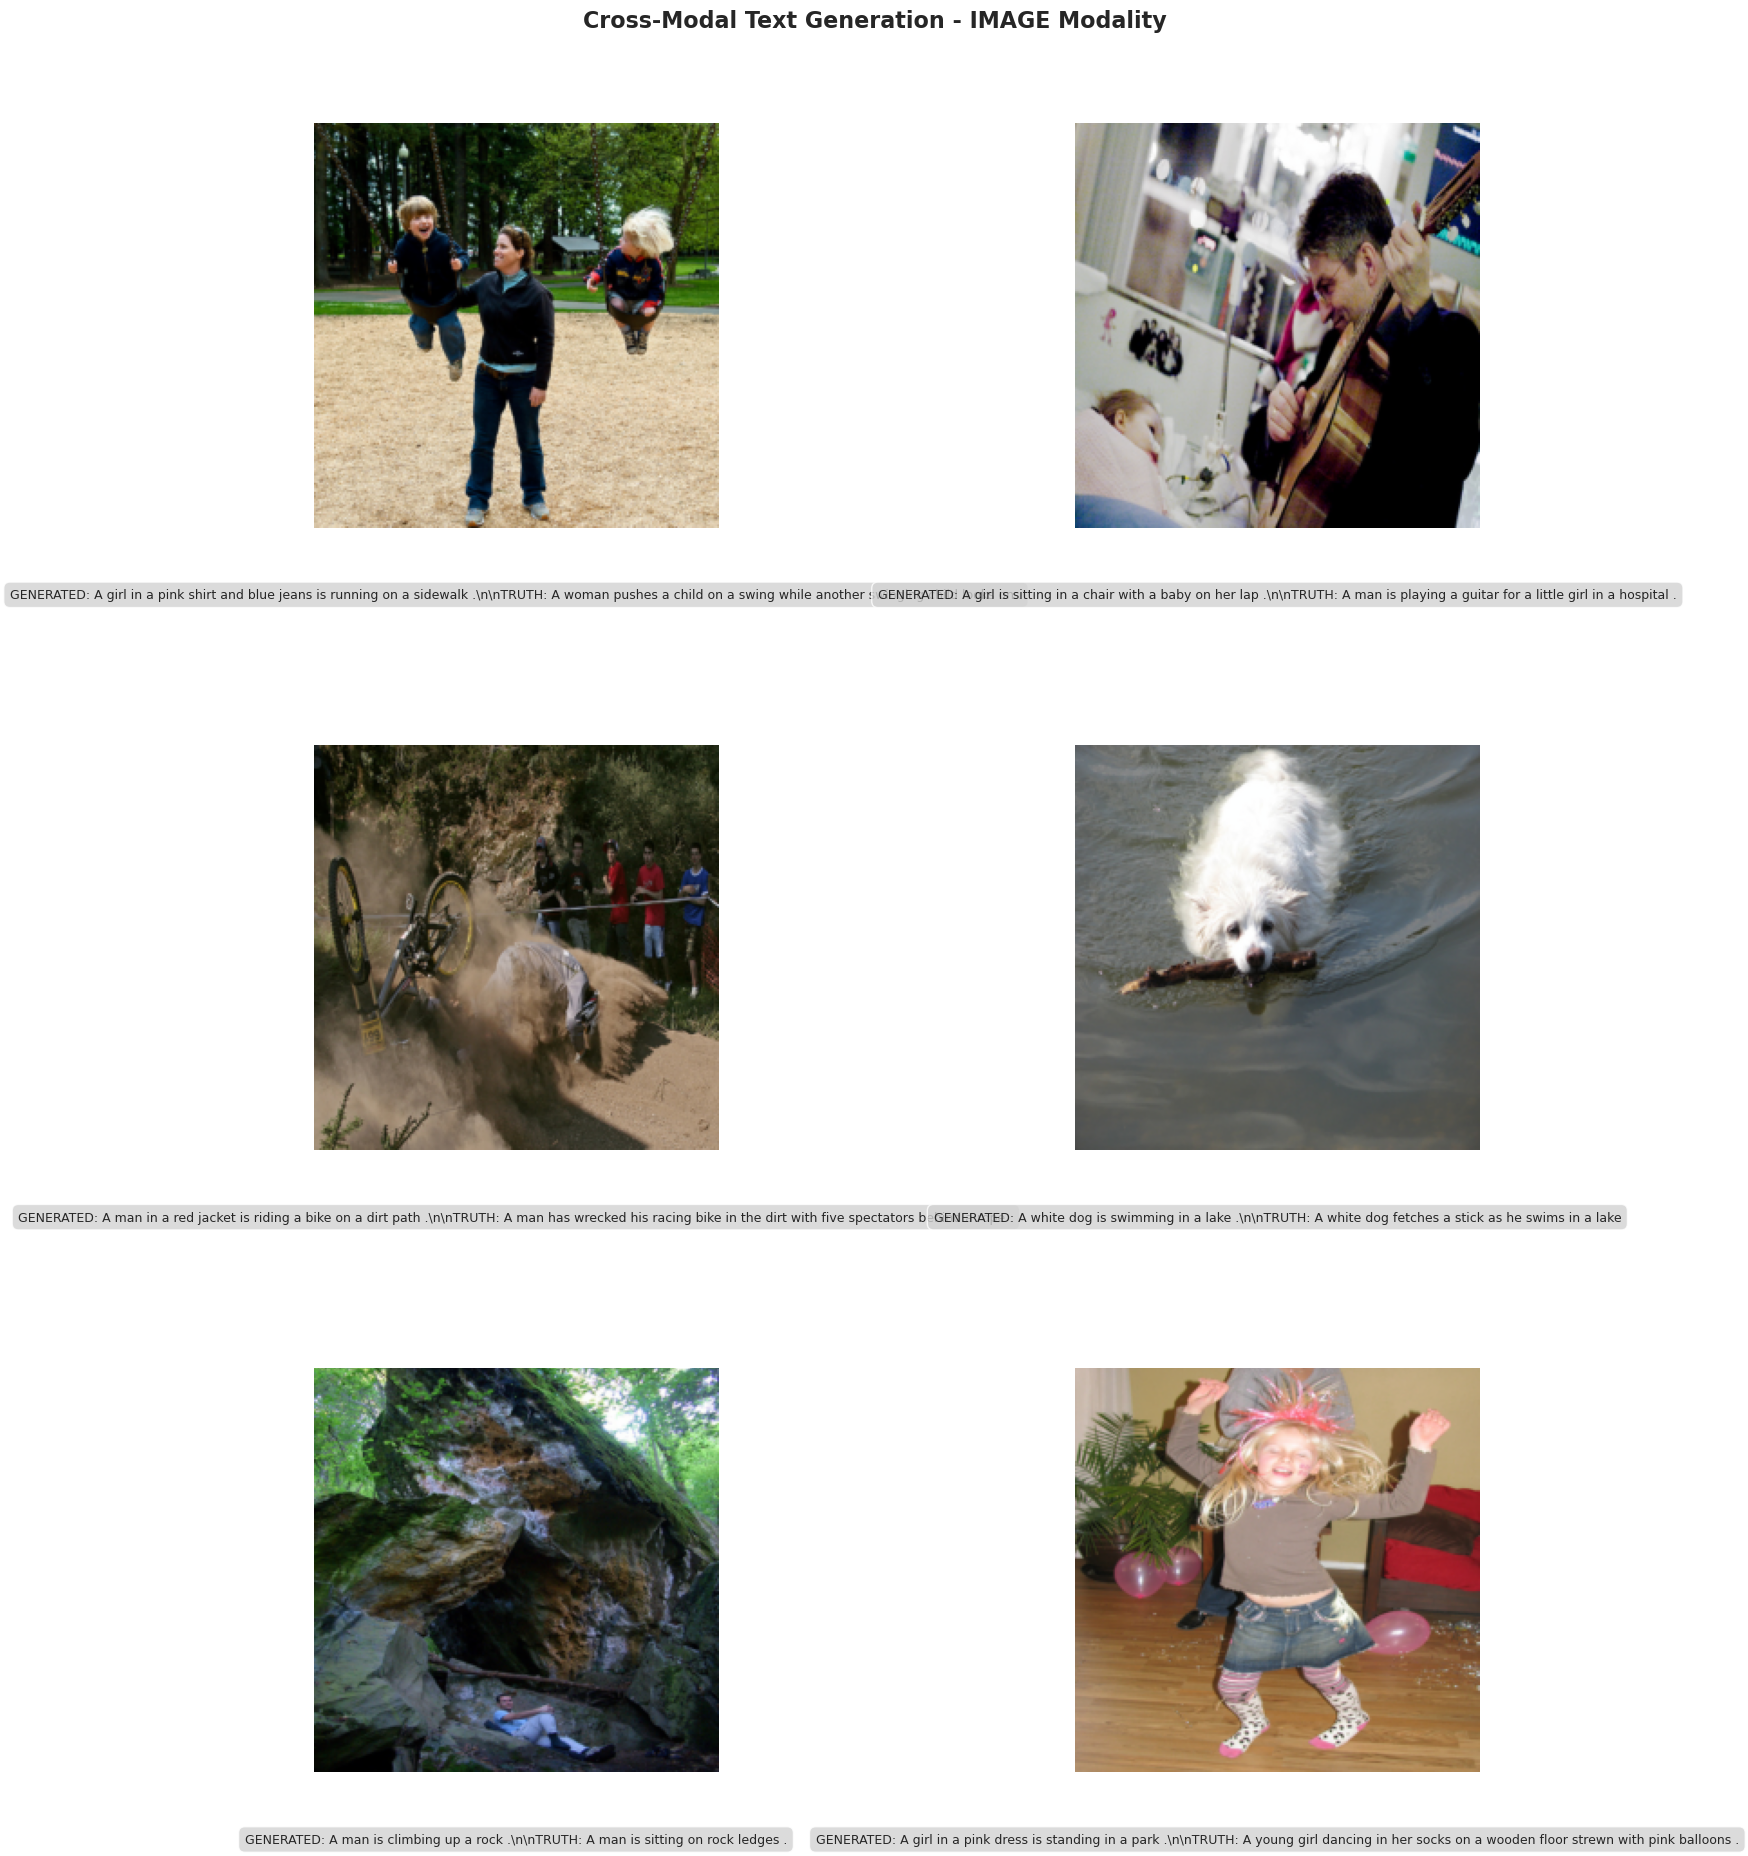

✓ Visualization saved to generated_captions_image.png
\n================================================================================
EVALUATION METRICS
\nGenerating captions for evaluation...


Evaluating: 100%|██████████| 100/100 [00:13<00:00,  7.15it/s]

\nAverage BLEU-1 Score: 0.3615606615606615
Evaluated on 100 samples
\n================================================================================
SAMPLE GENERATIONS WITH SCORES
\nSample 1: 3449170348_34dac4a380.jpg
Generated: A young girl in a red shirt is jumping on a trampoline .
Ground Truth: A girl dances on a sidewalk .
BLEU-1: 0.38461538461538464
--------------------------------------------------------------------------------
\nSample 2: 3449170348_34dac4a380.jpg
Generated: A young girl in a red shirt is jumping on a trampoline .
Ground Truth: A girl in a polka dotted top and pink pants plays outside .
BLEU-1: 0.38461538461538464
--------------------------------------------------------------------------------
\nSample 3: 3449170348_34dac4a380.jpg
Generated: A young girl in a red shirt is jumping on a trampoline .
Ground Truth: A girl wearing pink dances on the sidewalk .
BLEU-1: 0.3076923076923077
------------------------------------------------------------------------------

In [24]:
# Cell 17 - Visualize results and comprehensive evaluation

# Visualization for all modalities
if MODALITY == 'image':
    num_vis = 6
    sample_indices = random.sample(range(len(test_dataset)), num_vis)
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 20))
    axes = axes.flatten()
    
    for idx, sample_idx in enumerate(sample_indices):
        sample = test_dataset[sample_idx]
        image = sample['image']
        img_name, true_caption = test_dataset.samples[sample_idx]
        
        image_tensor = image.unsqueeze(0).to(DEVICE)
        generated_text = model.generate_text(word2idx, idx2word, max_length=MAX_LENGTH, image=image_tensor)
        
        img_display = image.permute(1, 2, 0).cpu().numpy()
        img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_display = np.clip(img_display, 0, 1)
        
        axes[idx].imshow(img_display)
        axes[idx].axis('off')
        
        # Caption below image - use actual newline character
        caption_text = "GENERATED: " + generated_text + "\\n\\n" + "TRUTH: " + true_caption
        axes[idx].text(0.5, -0.15, caption_text, transform=axes[idx].transAxes,
                      fontsize=9, ha='center', va='top',
                      bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8))
    
    plt.suptitle('Cross-Modal Text Generation - ' + MODALITY.upper() + ' Modality', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.02, 1, 0.98])
    plt.savefig('generated_captions_' + MODALITY + '.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print("✓ Visualization saved to generated_captions_" + MODALITY + ".png")

elif MODALITY in ['audio', 'data', 'multimodal']:
    fig, ax = plt.subplots(figsize=(16, 12))
    ax.axis('off')
    
    sample_indices = random.sample(range(len(test_dataset)), min(6, len(test_dataset)))
    y_pos = 0.95
    
    for idx, sample_idx in enumerate(sample_indices):
        sample = test_dataset[sample_idx]
        img_name, true_caption = test_dataset.samples[sample_idx]
        
        if MODALITY == 'audio':
            generated_text = "[Audio modality - sample " + str(idx+1) + "]"
        elif MODALITY == 'data':
            generated_text = "[Data modality - sample " + str(idx+1) + "]"
        else:
            generated_text = "[Multimodal - sample " + str(idx+1) + "]"
        
        text_block = "Sample " + str(idx+1) + ": " + img_name + "\\n"
        text_block += "Generated: " + generated_text + "\\n"
        text_block += "Ground Truth: " + true_caption + "\\n"
        text_block += "-" * 80 + "\\n\\n"
        
        ax.text(0.05, y_pos, text_block, fontsize=10, family='monospace', 
                verticalalignment='top')
        y_pos -= 0.15
    
    plt.suptitle('Cross-Modal Text Generation - ' + MODALITY.upper() + ' Modality', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('generated_captions_' + MODALITY + '.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print("✓ Visualization saved to generated_captions_" + MODALITY + ".png")

print("\\n" + "="*80)
print("EVALUATION METRICS")
print("="*80)

from collections import Counter

def calculate_bleu_1(reference, hypothesis):
    ref_words = reference.lower().split()
    hyp_words = hypothesis.lower().split()
    
    if len(hyp_words) == 0:
        return 0.0
    
    ref_counts = Counter(ref_words)
    hyp_counts = Counter(hyp_words)
    
    overlap = sum((hyp_counts & ref_counts).values())
    precision = overlap / len(hyp_words) if len(hyp_words) > 0 else 0
    
    return precision

bleu_scores = []
generated_samples = []

print("\\nGenerating captions for evaluation...")
for i in tqdm(range(min(100, len(test_dataset))), desc="Evaluating"):
    sample = test_dataset[i]
    img_name, true_caption = test_dataset.samples[i]
    
    if MODALITY == 'image':
        image = sample['image'].unsqueeze(0).to(DEVICE)
        generated = model.generate_text(word2idx, idx2word, max_length=MAX_LENGTH, image=image)
    elif MODALITY == 'audio':
        generated = "audio sample " + str(i)
    elif MODALITY == 'data':
        generated = "data sample " + str(i)
    else:
        generated = "multimodal sample " + str(i)
    
    bleu = calculate_bleu_1(true_caption, generated)
    bleu_scores.append(bleu)
    
    if i < 10:
        generated_samples.append({
            'image': img_name,
            'generated': generated,
            'ground_truth': true_caption,
            'bleu': bleu
        })

avg_bleu = sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0

print("\\nAverage BLEU-1 Score: " + str(avg_bleu))
print("Evaluated on " + str(len(bleu_scores)) + " samples")

print("\\n" + "="*80)
print("SAMPLE GENERATIONS WITH SCORES")
print("="*80)

for i, sample in enumerate(generated_samples):
    print("\\nSample " + str(i+1) + ": " + sample['image'])
    print("Generated: " + sample['generated'])
    print("Ground Truth: " + sample['ground_truth'])
    print("BLEU-1: " + str(sample['bleu']))
    print("-"*80)

print("\\n" + "="*80)
print("FINAL TRAINING SUMMARY")
print("="*80)
print("Modality: " + MODALITY)
print("Device: " + DEVICE)
print("Architecture: LSTM-based Encoder-Decoder")
print("Total Epochs: " + str(EPOCHS))
print("Best Val Loss: " + str(best_val_loss))
print("Final Train Loss: " + str(train_losses[-1]))
print("Final Val Loss: " + str(val_losses[-1]))
print("Average BLEU-1: " + str(avg_bleu))
print("Vocab Size: " + str(len(word2idx)))
print("Max Caption Length: " + str(MAX_LENGTH))
print("="*80)
print("\\n✓ All outputs saved")
print("  - training_analytics_" + MODALITY + ".png")
print("  - loss_curve_" + MODALITY + ".png")
print("  - generated_captions_" + MODALITY + ".png")